In [31]:
cd CSC311\csc311-food-prediction\Naive_Bayes

[WinError 3] The system cannot find the path specified: 'CSC311\\csc311-food-prediction\\Naive_Bayes'
c:\Users\shiha\Documents\UNI\year 3\CSC311\csc311-food-prediction\Naive_Bayes


C:\Users\shiha\AppData\Roaming\Python\Python312\site-packages\IPython\core\magics\osm.py:393: UserWarning: This is now an optional IPython functionality, using bookmarks requires you to install the `pickleshare` library.
  bkms = self.shell.db.get('bookmarks', {})


NOTE: no grid search was performed here, the grid search was performed in train_naive_bayes

In [32]:
import pandas as pd
import numpy as np
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report, 
    accuracy_score, 
    confusion_matrix, 
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)
import matplotlib.pyplot as plt
import sys
import re

sys.path.append('../csc311-food-prediction')

from Questions_7_8.cleaning_Q7_Q8 import process_data

from Questions_1_2.cleaning_Q1_Q2 import parse_q2_response

from cleanDataQ3Q6 import map_drink

from Questions_4_5.cleanQ4Q5 import create_movie_features

def process_q3q6_data(df):
    """
    Process Q3 (meal occasion) and Q6 (drink pairing) into bag of words features.
    
    Args:
        df: DataFrame containing the survey data
        
    Returns:
        q3_features: numpy array of shape (n_samples, n_q3_words)
        q6_features: numpy array of shape (n_samples, n_q6_words)
        q3_word_to_idx: dictionary mapping Q3 words to column indices
        q6_word_to_idx: dictionary mapping Q6 drinks to column indices
    """
    q3_col = [col for col in df.columns if 'Q3' in col][0]
    df[q3_col] = df[q3_col].fillna('').str.lower().str.strip()
    
    q6_col = [col for col in df.columns if 'Q6' in col][0]
    df[q6_col] = df[q6_col].fillna('').str.lower().str.strip()
    
    df[q6_col] = df[q6_col].apply(map_drink)
    
    all_q3_words = set()
    for response in df[q3_col].dropna():
        words = response.split(',')
        all_q3_words.update(word.strip() for word in words if word.strip())
    
    q3_word_to_idx = {word: idx for idx, word in enumerate(sorted(all_q3_words))}
    
    all_q6_words = set()
    for response in df[q6_col].dropna():
        words = response.split(',')
        all_q6_words.update(word.strip() for word in words if word.strip())
    
    q6_word_to_idx = {word: idx for idx, word in enumerate(sorted(all_q6_words))}
    
    n_samples = len(df)
    n_q3_words = len(q3_word_to_idx)
    n_q6_words = len(q6_word_to_idx)
    
    q3_features = np.zeros((n_samples, n_q3_words))
    q6_features = np.zeros((n_samples, n_q6_words))
    
    for i, response in enumerate(df[q3_col].fillna('')):
        if response:
            words = response.split(',')
            for word in words:
                word = word.strip()
                if word and word in q3_word_to_idx:
                    q3_features[i, q3_word_to_idx[word]] = 1
    
    for i, response in enumerate(df[q6_col].fillna('')):
        if response:
            words = response.split(',')
            for word in words:
                word = word.strip()
                if word and word in q6_word_to_idx:
                    q6_features[i, q6_word_to_idx[word]] = 1
    
    return q3_features, q6_features, q3_word_to_idx, q6_word_to_idx


def load_data(file_path):
    return pd.read_csv(file_path)

def process_q1_data(df):
    q1_col = [col for col in df.columns if 'Q1' in col][0]
    
    def extract_numeric(value):
        if pd.isna(value):
            return np.nan
        if isinstance(value, (int, float)):
            return float(value)
        matches = re.findall(r'\d+', str(value))
        if matches:
            return float(matches[0])
        return np.nan
    
    q1_values = df[q1_col].apply(extract_numeric)
    
    q1_features = np.array(q1_values).reshape(-1, 1)

    median_value = np.nanmedian(q1_features)
    q1_features = np.nan_to_num(q1_features, nan=median_value)
    
    return q1_features, "complexity_rating"

#same functions but replace NaN with median value
def process_q2_data_fix(df):
    q2_col = [col for col in df.columns if 'Q2' in col][0]
    
    word_bank_by_label = {
        'Pizza': {'cheese', 'tomato', 'dough', 'pepperoni', 'sauce', 'basil', 'water', 'oil', 'meat', 'olives'},
        'Shawarma': {'meat', 'pita', 'garlic', 'tahini', 'salad', 'onion', 'chicken', 'sauce', 'fries', 'rice'},
        'Sushi': {'rice', 'fish', 'seaweed', 'soy', 'wasabi', 'ginger', 'salmon', 'avocado'}
    }
    
    def clean_q2_row(row):
        bank = word_bank_by_label.get(row["Label"], None)
        return parse_q2_response(row[q2_col], word_bank=bank)
    
    q2_cleaned = df.apply(clean_q2_row, axis=1)
    
    q2_features = np.array(q2_cleaned).reshape(-1, 1)
    
    median_value = np.nanmedian(q2_features)
    q2_features = np.nan_to_num(q2_features, nan=median_value)
    
    return q2_features, "ingredient_count"

#same functions but replace NaN with median value
def process_q4_data_fix(df):
    q4_col = [col for col in df.columns if 'Q4' in col][0]
    
    def extract_price(value):
        if pd.isna(value):
            return np.nan
        if isinstance(value, (int, float)):
            return float(value)
        matches = re.findall(r'\d+(?:\.\d+)?', str(value))
        if matches:
            return float(max(matches, key=float))
        return np.nan
    
    q4_values = df[q4_col].apply(extract_price)
    
    q4_features = np.array(q4_values).reshape(-1, 1)
    
    median_value = np.nanmedian(q4_features)
    q4_features = np.nan_to_num(q4_features, nan=median_value)
    return q4_features, "price_expectation"

def plot_confusion_matrix(y_true, y_pred, labels):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    fig, ax = plt.subplots(figsize=(10, 8))
    disp.plot(ax=ax)
    plt.title('Confusion Matrix')
    plt.savefig('confusion_matrix.png')
    plt.show()

def plot_roc_curves(y_true, y_prob, labels):

    n_classes = len(labels)
    y_true_binary = np.zeros((len(y_true), n_classes))
    
    for i, label in enumerate(labels):
        y_true_binary[:, i] = (y_true == label)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    for i, label in enumerate(labels):
        fpr, tpr, _ = roc_curve(y_true_binary[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f'{label} (AUC = {roc_auc:.2f})')
    
    ax.plot([0, 1], [0, 1], 'k--')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('ROC Curves')
    ax.legend(loc="lower right")
    plt.savefig('roc_curves.png')
    plt.show()

def train_naive_bayes_model(df_train, df_valid):
    train_features_list = []
    valid_features_list = []
    feature_names = []
    
    q1_train_features, q1_name = process_q1_data(df_train)
    q1_valid_features, _ = process_q1_data(df_valid)
    
    train_features_list.append(q1_train_features)
    valid_features_list.append(q1_valid_features)
    feature_names.append(q1_name)
    
    q2_train_features, q2_name = process_q2_data_fix(df_train)
    q2_valid_features, _ = process_q2_data_fix(df_valid)
    
    train_features_list.append(q2_train_features)
    valid_features_list.append(q2_valid_features)
    feature_names.append(q2_name)
    
    q3_train_features, q6_train_features, q3_word_to_idx, q6_word_to_idx = process_q3q6_data(df_train)
    q3_valid_features = np.zeros((len(df_valid), len(q3_word_to_idx)))
    q6_valid_features = np.zeros((len(df_valid), len(q6_word_to_idx)))
    
    q3_col = [col for col in df_valid.columns if 'Q3' in col][0]
    q6_col = [col for col in df_valid.columns if 'Q6' in col][0]
    
    for i, response in enumerate(df_valid[q3_col].fillna('')):
        if response:
            response = response.lower().strip()
            words = response.split(',')
            for word in words:
                word = word.strip()
                if word and word in q3_word_to_idx:
                    q3_valid_features[i, q3_word_to_idx[word]] = 1
    
    for i, response in enumerate(df_valid[q6_col].fillna('')):
        if response:
            response = response.lower().strip()
            words = response.split(',')
            for word in words:
                word = word.strip()
                if word and word in q6_word_to_idx:
                    q6_valid_features[i, q6_word_to_idx[word]] = 1
    
    train_features_list.append(q3_train_features)
    train_features_list.append(q6_train_features)
    valid_features_list.append(q3_valid_features)
    valid_features_list.append(q6_valid_features)
    
    feature_names.extend([f'q3_{word}' for word in q3_word_to_idx.keys()])
    feature_names.extend([f'q6_{word}' for word in q6_word_to_idx.keys()])
    
    q4_train_features, q4_name = process_q4_data_fix(df_train)
    q4_valid_features, _ = process_q4_data_fix(df_valid)
    
    train_features_list.append(q4_train_features)
    valid_features_list.append(q4_valid_features)
    feature_names.append(q4_name)
    q5_train_features, q5_word_to_idx = create_movie_features(df_train)
    
    q5_valid_features = np.zeros((len(df_valid), len(q5_word_to_idx)))
    
    q5_col = [col for col in df_valid.columns if 'Q5' in col][0]
    for i, response in enumerate(df_valid[q5_col].fillna('')):
        if response:
            response = response.lower().strip()
            movies = response.split(',')
            for movie in movies:
                movie = movie.strip()
                if movie in q5_word_to_idx:
                    q5_valid_features[i, q5_word_to_idx[movie]] = 1
    
    train_features_list.append(q5_train_features)
    valid_features_list.append(q5_valid_features)
    feature_names.extend([f'q5_{movie}' for movie in q5_word_to_idx.keys()])
    
    q7_train_features, q8_train_features, q7_word_to_idx, q8_category_to_idx = process_data(df_train)
    
    q7_valid_features, q8_valid_features, _, _ = process_data(df_valid)
    
    train_features_list.append(q7_train_features)
    train_features_list.append(q8_train_features)
    valid_features_list.append(q7_valid_features)
    valid_features_list.append(q8_valid_features)
    
    feature_names.extend([f'q7_{word}' for word in q7_word_to_idx.keys()])
    feature_names.extend([f'q8_{cat}' for cat in q8_category_to_idx.keys()])
    
    X_train = np.hstack(train_features_list) if train_features_list else np.array([])
    X_valid = np.hstack(valid_features_list) if valid_features_list else np.array([])
    
    y_train = df_train['Label'].values
    y_valid = df_valid['Label'].values
    
    model = MultinomialNB(alpha=0.1)
    model.fit(X_train, y_train)
    
    y_valid_pred = model.predict(X_valid)
    y_valid_prob = model.predict_proba(X_valid)
    
    y_train_pred = model.predict(X_train)
    
    valid_accuracy = accuracy_score(y_valid, y_valid_pred)
    train_accuracy = accuracy_score(y_train, y_train_pred)
    report = classification_report(y_valid, y_valid_pred)
    
    plot_confusion_matrix(y_valid, y_valid_pred, model.classes_)
    plot_roc_curves(y_valid, y_valid_prob, model.classes_)
    
    return valid_accuracy, train_accuracy, report, model, feature_names, X_train.shape

       id  \
0  716549   
1  715742   
2  727333   
3  606874   
4  505318   

   Q1: From a scale 1 to 5, how complex is it to make this food? (Where 1 is the most simple, and 5 is the most complex)  \
0                                                  3                                                                       
1                                                  4                                                                       
2                                                  3                                                                       
3                                                  4                                                                       
4                                                  2                                                                       

  Q2: How many ingredients would you expect this food item to contain?  \
0                                                  6                     
1                           

C:\Users\shiha\AppData\Local\Temp\ipykernel_32808\1412977257.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[q3_col] = df[q3_col].fillna('').str.lower().str.strip()
C:\Users\shiha\AppData\Local\Temp\ipykernel_32808\1412977257.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[q6_col] = df[q6_col].fillna('').str.lower().str.strip()
C:\Users\shiha\AppData\Local\Temp\ipykernel_32808\1412977257.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try us

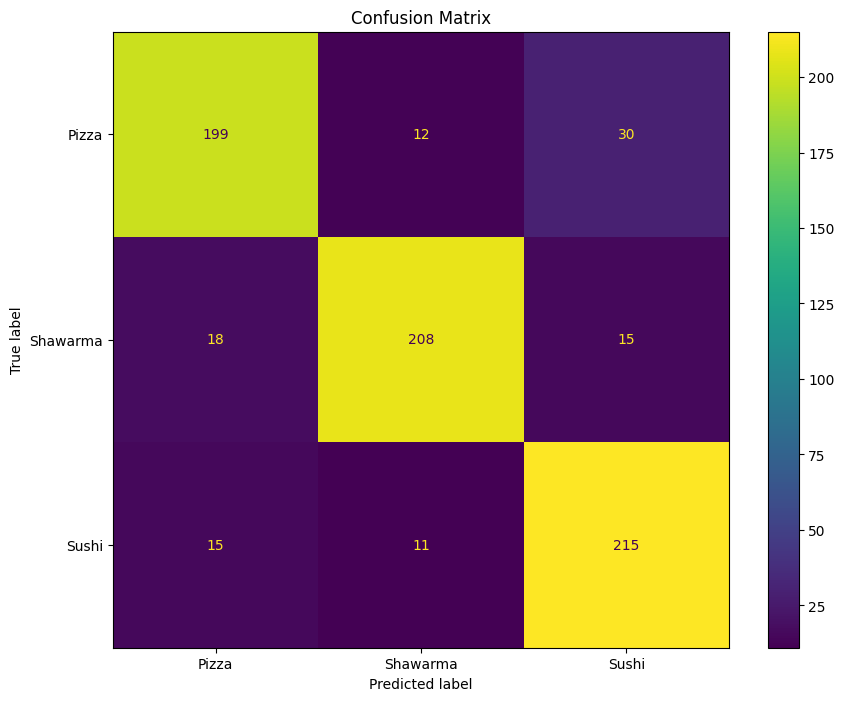

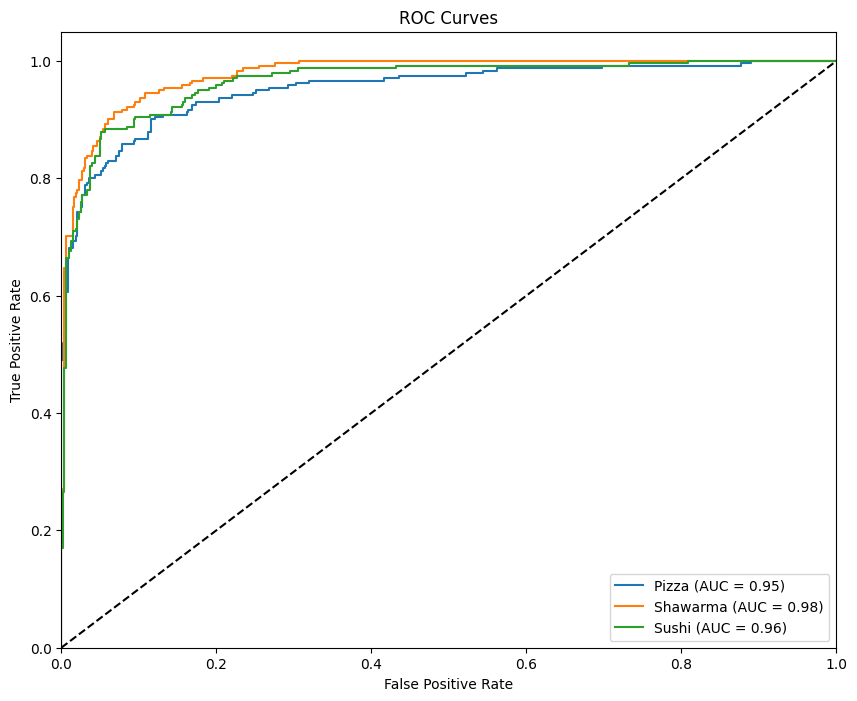

In [33]:
train_data_path = "../cleaned_data_combined.csv"
df = pd.read_csv(train_data_path)
print(df.head())

valid_size = 723
df_valid = df.iloc[:valid_size]
df_train = df.iloc[valid_size:]

print(f"Validation data size: {len(df_valid)} rows")
print(f"Training data size: {len(df_train)} rows")

# df_train, df_valid = train_test_split(df, test_size=0.2)

valid_accuracy, train_accuracy, report, model, feature_names, _ = train_naive_bayes_model(df_train, df_valid)

In [34]:
for i, label in enumerate(model.classes_):
    print(f"\nTop 15 features for {label}:")
    log_probs = model.feature_log_prob_[i]
    indices = np.argsort(log_probs)[-15:] 
    for idx in reversed(indices):
        if idx < len(feature_names):
            print(f"  {feature_names[idx]}: {np.exp(log_probs[idx]):.4f}")


Top 15 features for Pizza:
  price_expectation: 0.3298
  ingredient_count: 0.2292
  complexity_rating: 0.1006
  q3_at a party: 0.0336
  q7_Friends: 0.0312
  q3_week day lunch: 0.0264
  q3_weekend dinner: 0.0256
  q3_weekend lunch: 0.0251
  q3_week day dinner: 0.0229
  q3_late night snack: 0.0210
  q8_None: 0.0179
  q6_coca-cola: 0.0164
  q7_Siblings: 0.0146
  q7_Parents: 0.0116
  q8_A little (mild): 0.0096

Top 15 features for Shawarma:
  price_expectation: 0.3762
  ingredient_count: 0.2428
  complexity_rating: 0.1086
  q3_week day lunch: 0.0294
  q3_weekend lunch: 0.0247
  q7_Friends: 0.0224
  q3_week day dinner: 0.0215
  q3_weekend dinner: 0.0172
  q8_A moderate amount (medium): 0.0134
  q7_Strangers: 0.0126
  q7_Parents: 0.0108
  q7_Siblings: 0.0103
  q3_late night snack: 0.0101
  q6_coca-cola: 0.0084
  q5_the avengers: 0.0072

Top 15 features for Sushi:
  price_expectation: 0.4674
  ingredient_count: 0.1585
  complexity_rating: 0.1081
  q3_weekend dinner: 0.0255
  q8_None: 0.0215


In [35]:
print(f"\nTraining Accuracy: {train_accuracy:.4f}")
print(f"Validation Accuracy: {valid_accuracy:.4f}")
print("\nClassification Report:")
print(report)


Training Accuracy: 0.9435
Validation Accuracy: 0.8603

Classification Report:
              precision    recall  f1-score   support

       Pizza       0.86      0.83      0.84       241
    Shawarma       0.90      0.86      0.88       241
       Sushi       0.83      0.89      0.86       241

    accuracy                           0.86       723
   macro avg       0.86      0.86      0.86       723
weighted avg       0.86      0.86      0.86       723



Model has issues with predicting pizza as sushi, which is likely because of the high amount of shared attributes between them, which you can see in the initial data analysis.